# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

## Overview
DBSCAN groups together points that are **closely packed** (high density) and marks points in low-density regions as **outliers/noise**. Unlike K-Means and Hierarchical Clustering, DBSCAN:
- Does **not** require K to be specified
- Can find **arbitrarily shaped** clusters
- Automatically detects **outliers/noise** (labeled -1)

### Core Concepts:
**Two parameters:**
- $\epsilon$ (`eps`): radius of neighborhood around a point
- `min_samples`: minimum points required in $\epsilon$-neighborhood to be a core point

**Three types of points:**
| Type | Definition |
|------|------------|
| **Core point** | Has $\geq$ `min_samples` points within $\epsilon$ distance |
| **Border point** | Within $\epsilon$ of a core point, but has $<$ `min_samples` neighbors |
| **Noise point** | Neither core nor border — labeled **-1** |

### Algorithm:
1. For each unvisited point $p$:
   - Find all points within $\epsilon$ of $p$
   - If $|N_\epsilon(p)| \geq$ `min_samples` → $p$ is a **core point**, start a cluster
   - Recursively expand cluster by adding density-reachable points
   - Else → mark as noise (may be relabeled as border later)

### Complexity: $O(n \log n)$ with spatial indexing

---
### Topics Covered
1. Core / Border / Noise point visualization
2. DBSCAN on non-spherical datasets (moons, circles, blobs)
3. Effect of eps and min_samples
4. Selecting eps with k-distance graph
5. Outlier detection
6. Comparing DBSCAN vs K-Means vs Hierarchical
7. Real-world offline-safe dataset — geospatial-style clustering
8. Evaluation metrics
9. DBSCAN limitations and HDBSCAN preview


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.datasets import make_blobs, make_moons, make_circles

COLORS = {
    'primary':   '#2E86AB',
    'secondary': '#E67E22',
    'tertiary':  '#9B59B6',
    'success':   '#27AE60',
    'danger':    '#E74C3C',
    'neutral':   '#7F8C8D',
    'noise':     '#2C3E50',
}
CLUSTER_COLORS = ['#E74C3C','#2E86AB','#27AE60','#E67E22',
                  '#9B59B6','#F39C12','#1ABC9C','#E91E63']

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('Libraries imported successfully!')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Libraries imported successfully!
NumPy  : 1.26.4
Pandas : 2.3.3


## 2. Core / Border / Noise Points — Visual Intuition

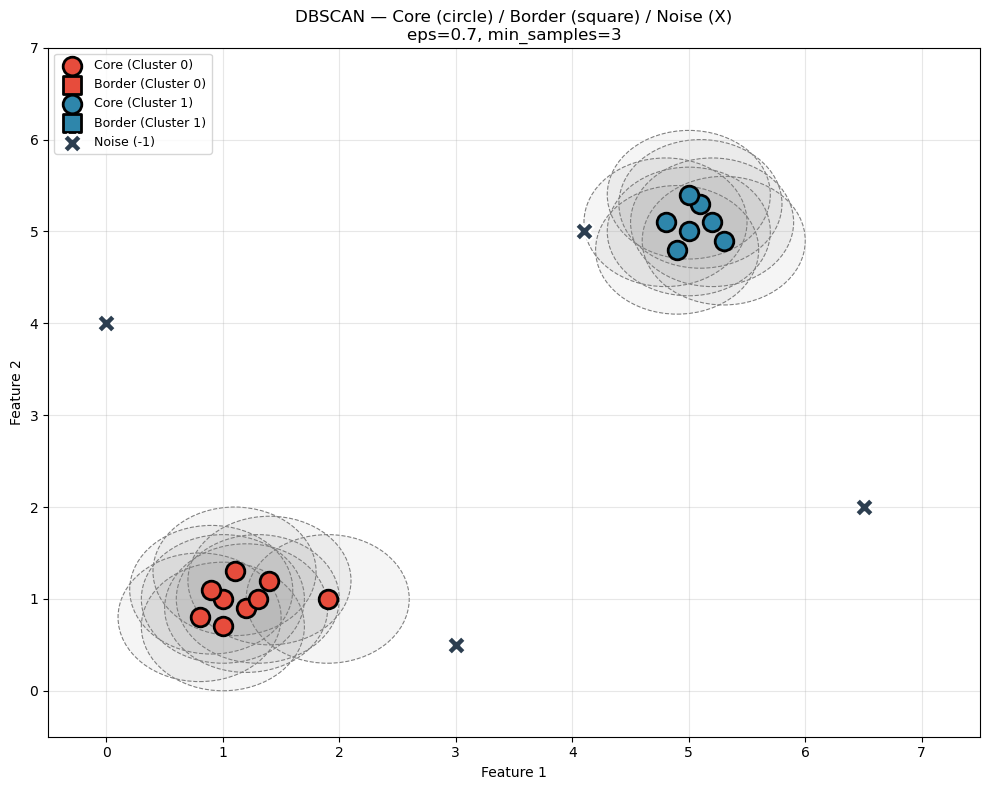

Core points   : 16
Border points : 0
Noise points  : 4
Clusters found: 2


In [2]:
np.random.seed(42)

# Small hand-crafted dataset to show all 3 point types clearly
X_demo = np.array([
    # Dense cluster A
    [1.0, 1.0], [1.2, 0.9], [0.9, 1.1], [1.1, 1.3], [1.3, 1.0],
    [0.8, 0.8], [1.4, 1.2], [1.0, 0.7],
    # Border point near cluster A
    [1.9, 1.0],
    # Dense cluster B
    [5.0, 5.0], [5.2, 5.1], [4.9, 4.8], [5.1, 5.3], [4.8, 5.1],
    [5.3, 4.9], [5.0, 5.4],
    # Border near cluster B
    [4.1, 5.0],
    # Noise points
    [3.0, 0.5], [0.0, 4.0], [6.5, 2.0],
])

eps_demo      = 0.7
min_samp_demo = 3

db_demo   = DBSCAN(eps=eps_demo, min_samples=min_samp_demo)
lbl_demo  = db_demo.fit_predict(X_demo)
core_mask = np.zeros(len(X_demo), dtype=bool)
core_mask[db_demo.core_sample_indices_] = True

fig, ax = plt.subplots(figsize=(10, 8))

# Draw eps circles around core points
for idx in db_demo.core_sample_indices_:
    circle = plt.Circle(X_demo[idx], eps_demo, color='gray',
                        fill=True, alpha=0.08, linewidth=0)
    ax.add_patch(circle)
    circle_edge = plt.Circle(X_demo[idx], eps_demo, color='gray',
                             fill=False, linewidth=0.8, linestyle='--')
    ax.add_patch(circle_edge)

# Core points
for k in np.unique(lbl_demo[lbl_demo >= 0]):
    mask_core   = (lbl_demo == k) & core_mask
    mask_border = (lbl_demo == k) & ~core_mask
    ax.scatter(X_demo[mask_core, 0], X_demo[mask_core, 1],
               color=CLUSTER_COLORS[k], s=180, edgecolors='black',
               linewidths=2, zorder=5, label=f'Core (Cluster {k})')
    ax.scatter(X_demo[mask_border, 0], X_demo[mask_border, 1],
               color=CLUSTER_COLORS[k], s=180, edgecolors='black',
               linewidths=2, marker='s', zorder=5, label=f'Border (Cluster {k})')

# Noise
noise_mask = lbl_demo == -1
ax.scatter(X_demo[noise_mask, 0], X_demo[noise_mask, 1],
           color=COLORS['noise'], s=180, marker='X', edgecolors='white',
           linewidths=1.5, zorder=5, label='Noise (-1)')

ax.set_xlim(-0.5, 7.5); ax.set_ylim(-0.5, 7)
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.set_title(f'DBSCAN — Core (circle) / Border (square) / Noise (X)\n'
             f'eps={eps_demo}, min_samples={min_samp_demo}')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

n_core   = core_mask.sum()
n_border = ((lbl_demo >= 0) & ~core_mask).sum()
n_noise  = (lbl_demo == -1).sum()
print(f'Core points   : {n_core}')
print(f'Border points : {n_border}')
print(f'Noise points  : {n_noise}')
print(f'Clusters found: {len(np.unique(lbl_demo[lbl_demo >= 0]))}')

## 3. DBSCAN on Non-Spherical Datasets

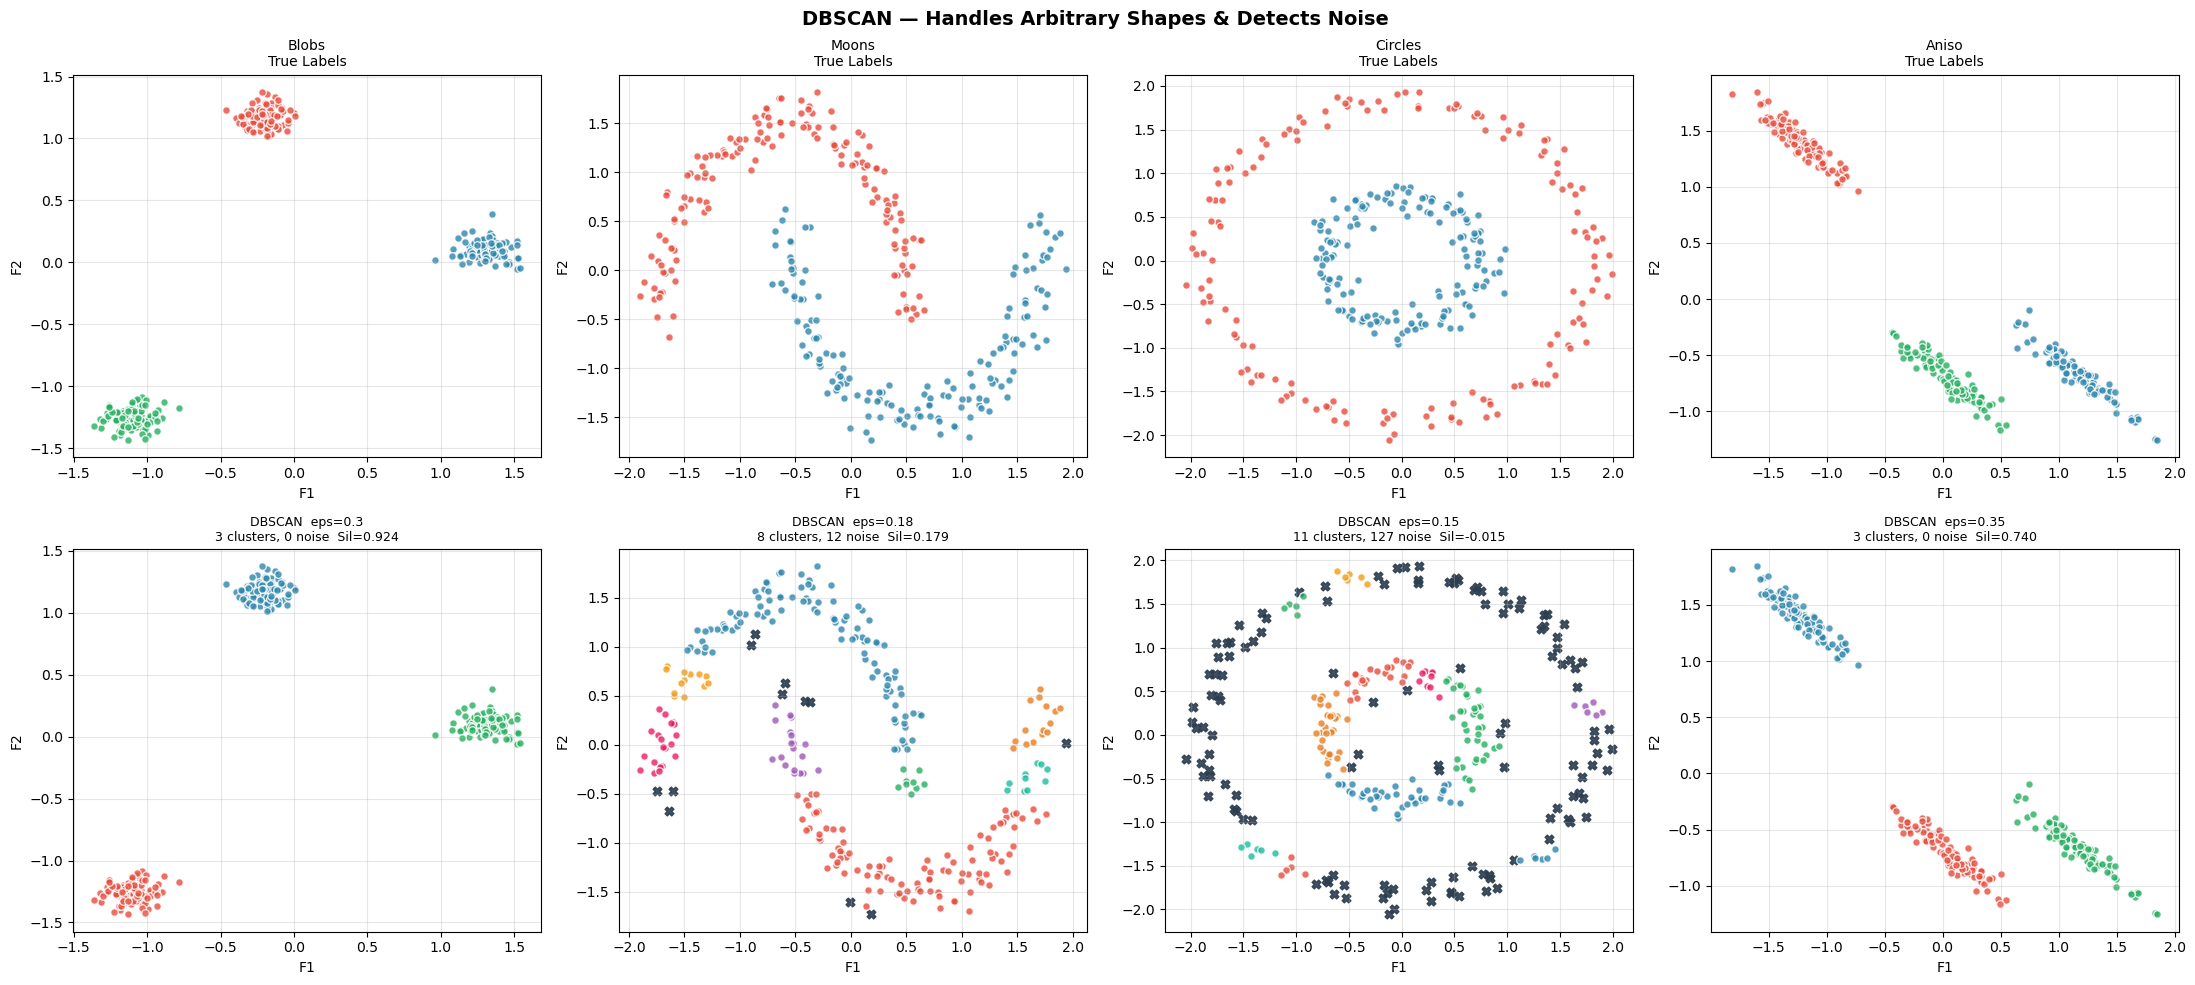

In [3]:
np.random.seed(42)
datasets = {
    'Blobs':   (make_blobs(n_samples=300, centers=3,
                           cluster_std=0.5, random_state=42),
                0.3, 5),
    'Moons':   (make_moons(n_samples=300, noise=0.07, random_state=42),
                0.18, 5),
    'Circles': (make_circles(n_samples=300, noise=0.05,
                             factor=0.4, random_state=42),
                0.15, 5),
    'Aniso':   (None, 0.35, 5),   # anisotropic blobs
}

# Build anisotropic
np.random.seed(42)
X_aniso, y_aniso = make_blobs(n_samples=300, centers=3, random_state=42)
T = np.array([[0.6, -0.6], [-0.4, 0.8]])
X_aniso = X_aniso @ T
datasets['Aniso'] = ((X_aniso, y_aniso), 0.35, 5)

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for col, (name, ((X_ds, y_ds), eps_ds, min_s)) in enumerate(datasets.items()):
    X_ds_sc = StandardScaler().fit_transform(X_ds)
    db       = DBSCAN(eps=eps_ds, min_samples=min_s)
    lbl      = db.fit_predict(X_ds_sc)
    n_clust  = len(np.unique(lbl[lbl >= 0]))
    n_noise  = (lbl == -1).sum()
    sil      = silhouette_score(X_ds_sc, lbl) if n_clust > 1 and n_clust < len(lbl)-1 else np.nan

    # True labels
    for k in np.unique(y_ds):
        axes[0][col].scatter(X_ds_sc[y_ds==k, 0], X_ds_sc[y_ds==k, 1],
                             color=CLUSTER_COLORS[int(k)], s=30, alpha=0.8, edgecolors='white')
    axes[0][col].set_title(f'{name}\nTrue Labels', fontsize=10)

    # DBSCAN labels
    for k in np.unique(lbl):
        mask = lbl == k
        if k == -1:
            axes[1][col].scatter(X_ds_sc[mask, 0], X_ds_sc[mask, 1],
                                 color=COLORS['noise'], s=40, marker='X',
                                 alpha=0.9, label='Noise')
        else:
            axes[1][col].scatter(X_ds_sc[mask, 0], X_ds_sc[mask, 1],
                                 color=CLUSTER_COLORS[k % len(CLUSTER_COLORS)],
                                 s=30, alpha=0.8, edgecolors='white')
    sil_str = f'{sil:.3f}' if not np.isnan(sil) else 'N/A'
    axes[1][col].set_title(
        f'DBSCAN  eps={eps_ds}\n{n_clust} clusters, {n_noise} noise  Sil={sil_str}',
        fontsize=9
    )
    for ax in [axes[0][col], axes[1][col]]:
        ax.set_xlabel('F1'); ax.set_ylabel('F2')

plt.suptitle('DBSCAN — Handles Arbitrary Shapes & Detects Noise',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Effect of eps and min_samples

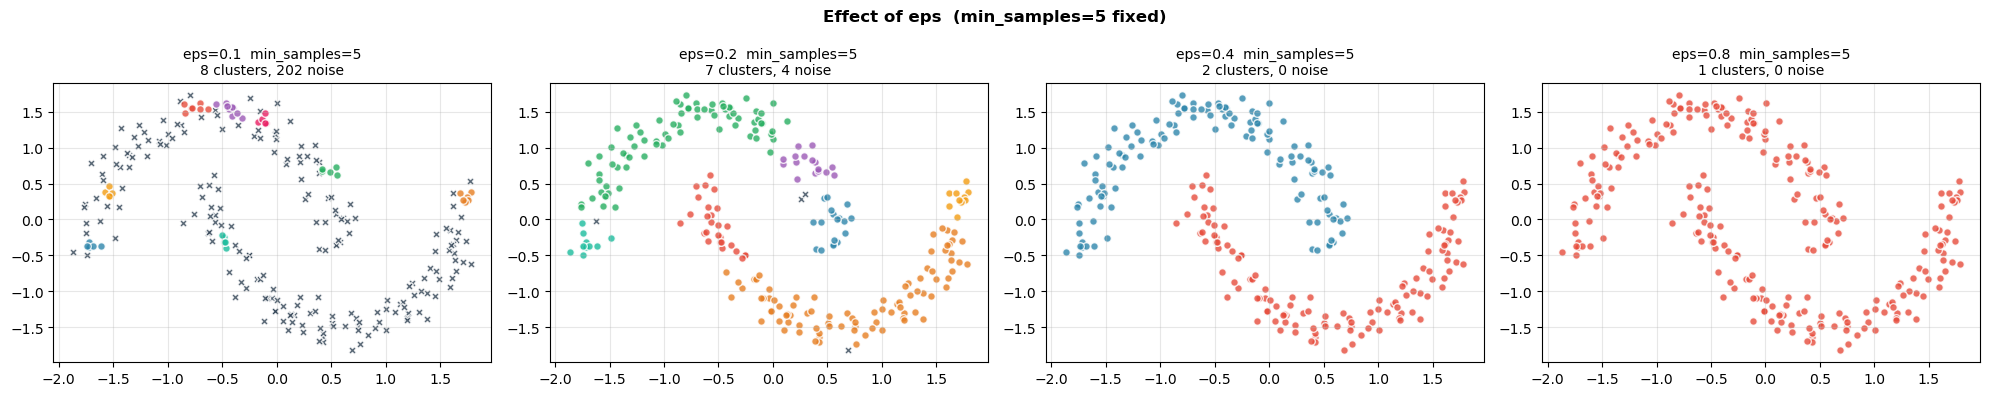

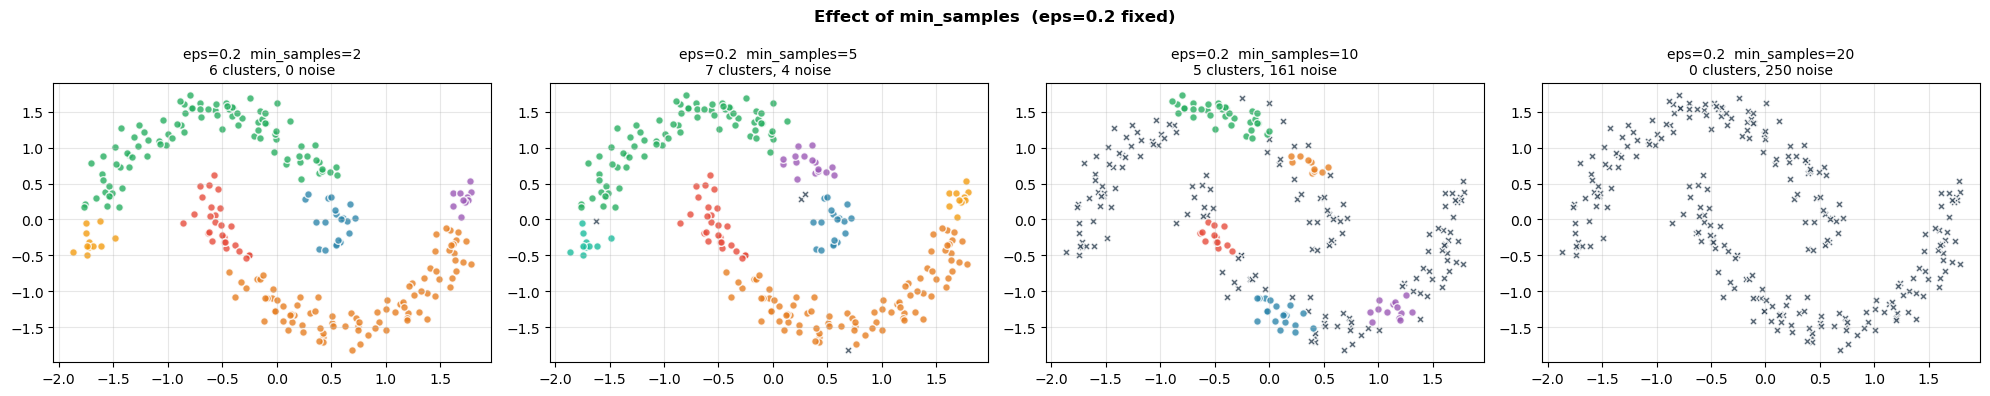

eps too small   -> too many noise points, clusters fragmented
eps too large   -> everything merged into one cluster
min_samples too small -> noise points become clusters
min_samples too large -> legitimate points labeled as noise


In [4]:
np.random.seed(42)
X_eff, _ = make_moons(n_samples=250, noise=0.08, random_state=42)
X_eff_sc  = StandardScaler().fit_transform(X_eff)

eps_values     = [0.1, 0.2, 0.4, 0.8]
minsamp_values = [2, 5, 10, 20]

# --- Effect of eps (min_samples fixed at 5) ---
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, eps_v in zip(axes, eps_values):
    lbl  = DBSCAN(eps=eps_v, min_samples=5).fit_predict(X_eff_sc)
    nc   = len(np.unique(lbl[lbl >= 0]))
    nn   = (lbl == -1).sum()
    for k in np.unique(lbl):
        mask = lbl == k
        color = COLORS['noise'] if k == -1 else CLUSTER_COLORS[k % len(CLUSTER_COLORS)]
        marker = 'X' if k == -1 else 'o'
        ax.scatter(X_eff_sc[mask, 0], X_eff_sc[mask, 1],
                   color=color, s=30, marker=marker, alpha=0.8, edgecolors='white')
    ax.set_title(f'eps={eps_v}  min_samples=5\n{nc} clusters, {nn} noise', fontsize=10)
plt.suptitle('Effect of eps  (min_samples=5 fixed)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Effect of min_samples (eps fixed at 0.2) ---
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, ms_v in zip(axes, minsamp_values):
    lbl  = DBSCAN(eps=0.2, min_samples=ms_v).fit_predict(X_eff_sc)
    nc   = len(np.unique(lbl[lbl >= 0]))
    nn   = (lbl == -1).sum()
    for k in np.unique(lbl):
        mask = lbl == k
        color = COLORS['noise'] if k == -1 else CLUSTER_COLORS[k % len(CLUSTER_COLORS)]
        marker = 'X' if k == -1 else 'o'
        ax.scatter(X_eff_sc[mask, 0], X_eff_sc[mask, 1],
                   color=color, s=30, marker=marker, alpha=0.8, edgecolors='white')
    ax.set_title(f'eps=0.2  min_samples={ms_v}\n{nc} clusters, {nn} noise', fontsize=10)
plt.suptitle('Effect of min_samples  (eps=0.2 fixed)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('eps too small   -> too many noise points, clusters fragmented')
print('eps too large   -> everything merged into one cluster')
print('min_samples too small -> noise points become clusters')
print('min_samples too large -> legitimate points labeled as noise')

## 5. Selecting eps — k-Distance Graph

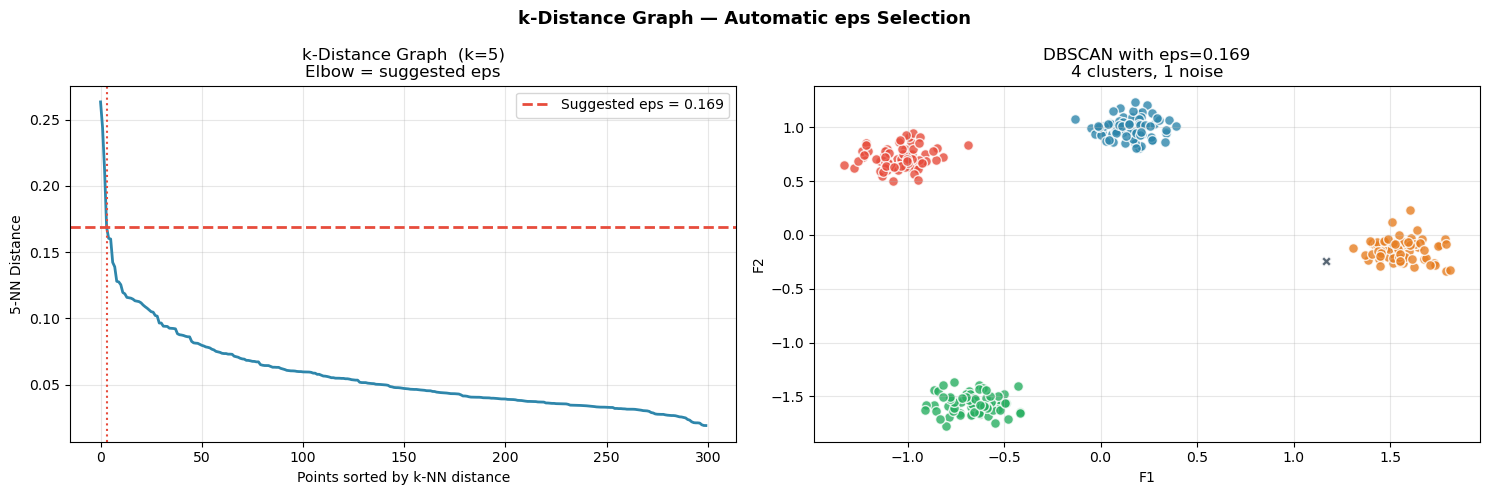

Suggested eps from k-distance elbow : 0.1689
Clusters found                      : 4
Noise points                        : 1

Rule: the elbow in the k-distance graph indicates the natural density threshold.
Points above the elbow are in sparse (noise) regions.


In [5]:
np.random.seed(42)
X_kd, _ = make_blobs(n_samples=300, centers=4,
                      cluster_std=0.6, random_state=42)
X_kd_sc  = StandardScaler().fit_transform(X_kd)

min_samples_kd = 5

# Fit NearestNeighbors to get k-th nearest distances
nbrs = NearestNeighbors(n_neighbors=min_samples_kd)
nbrs.fit(X_kd_sc)
distances, _ = nbrs.kneighbors(X_kd_sc)
k_distances  = np.sort(distances[:, -1])[::-1]   # k-th NN distance, sorted desc

# Find the elbow
diffs      = np.diff(k_distances)
elbow_idx  = np.argmax(np.abs(diffs)) + 1
eps_elbow  = k_distances[elbow_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(k_distances, color=COLORS['primary'], linewidth=2)
ax1.axhline(eps_elbow, color=COLORS['danger'], linestyle='--',
            linewidth=2, label=f'Suggested eps = {eps_elbow:.3f}')
ax1.axvline(elbow_idx, color=COLORS['danger'], linestyle=':',
            linewidth=1.5)
ax1.set_xlabel('Points sorted by k-NN distance')
ax1.set_ylabel(f'{min_samples_kd}-NN Distance')
ax1.set_title(f'k-Distance Graph  (k={min_samples_kd})\nElbow = suggested eps')
ax1.legend()

# Apply DBSCAN with suggested eps
lbl_kd  = DBSCAN(eps=eps_elbow, min_samples=min_samples_kd).fit_predict(X_kd_sc)
n_clust = len(np.unique(lbl_kd[lbl_kd >= 0]))
n_noise = (lbl_kd == -1).sum()

for k in np.unique(lbl_kd):
    mask   = lbl_kd == k
    color  = COLORS['noise'] if k == -1 else CLUSTER_COLORS[k % len(CLUSTER_COLORS)]
    marker = 'X' if k == -1 else 'o'
    ax2.scatter(X_kd_sc[mask, 0], X_kd_sc[mask, 1],
                color=color, s=50, marker=marker,
                alpha=0.8, edgecolors='white')
ax2.set_title(f'DBSCAN with eps={eps_elbow:.3f}\n{n_clust} clusters, {n_noise} noise')
ax2.set_xlabel('F1'); ax2.set_ylabel('F2')

plt.suptitle('k-Distance Graph — Automatic eps Selection',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Suggested eps from k-distance elbow : {eps_elbow:.4f}')
print(f'Clusters found                      : {n_clust}')
print(f'Noise points                        : {n_noise}')
print()
print('Rule: the elbow in the k-distance graph indicates the natural density threshold.')
print('Points above the elbow are in sparse (noise) regions.')

## 6. DBSCAN for Outlier / Anomaly Detection

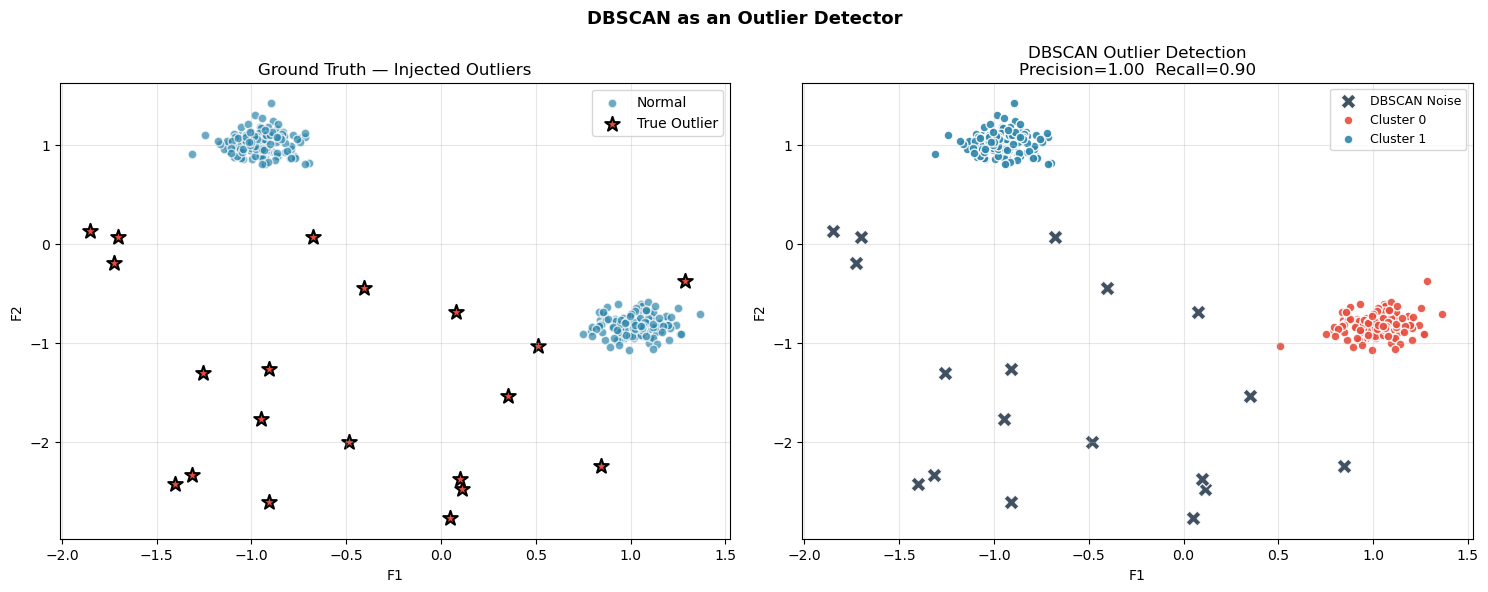

True outliers injected    : 20
DBSCAN noise points       : 18
True Positives            : 18
False Positives           : 0
False Negatives           : 2
Outlier Detection Precision: 1.0000
Outlier Detection Recall   : 0.9000


In [6]:
np.random.seed(42)
n_normal  = 300
n_outlier = 20

# Normal data — two compact clusters
X_norm, _ = make_blobs(n_samples=n_normal, centers=2,
                        cluster_std=0.4, random_state=42)
# Inject outliers scattered randomly
X_out  = np.random.uniform(-6, 6, (n_outlier, 2))
X_full = np.vstack([X_norm, X_out])
true_outlier = np.array([0]*n_normal + [1]*n_outlier)

X_full_sc = StandardScaler().fit_transform(X_full)

db_out   = DBSCAN(eps=0.3, min_samples=8)
lbl_out  = db_out.fit_predict(X_full_sc)
pred_outlier = (lbl_out == -1).astype(int)

# Evaluation
tp = ((pred_outlier == 1) & (true_outlier == 1)).sum()
fp = ((pred_outlier == 1) & (true_outlier == 0)).sum()
fn = ((pred_outlier == 0) & (true_outlier == 1)).sum()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# True outliers
axes[0].scatter(X_full_sc[true_outlier==0, 0], X_full_sc[true_outlier==0, 1],
                color=COLORS['primary'], s=40, alpha=0.7,
                edgecolors='white', label='Normal')
axes[0].scatter(X_full_sc[true_outlier==1, 0], X_full_sc[true_outlier==1, 1],
                color=COLORS['danger'], s=120, marker='*',
                edgecolors='black', linewidths=1.5, label='True Outlier')
axes[0].set_title('Ground Truth — Injected Outliers')
axes[0].legend()

# DBSCAN detections
for k in np.unique(lbl_out):
    mask   = lbl_out == k
    color  = COLORS['noise'] if k == -1 else CLUSTER_COLORS[k % len(CLUSTER_COLORS)]
    marker = 'X' if k == -1 else 'o'
    size   = 120 if k == -1 else 40
    lbl_str = 'DBSCAN Noise' if k == -1 else f'Cluster {k}'
    axes[1].scatter(X_full_sc[mask, 0], X_full_sc[mask, 1],
                    color=color, s=size, marker=marker,
                    alpha=0.9, edgecolors='white', label=lbl_str)
axes[1].set_title(
    f'DBSCAN Outlier Detection\nPrecision={precision:.2f}  Recall={recall:.2f}'
)
axes[1].legend(fontsize=9)

for ax in axes:
    ax.set_xlabel('F1'); ax.set_ylabel('F2')

plt.suptitle('DBSCAN as an Outlier Detector', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'True outliers injected    : {n_outlier}')
print(f'DBSCAN noise points       : {(lbl_out==-1).sum()}')
print(f'True Positives            : {tp}')
print(f'False Positives           : {fp}')
print(f'False Negatives           : {fn}')
print(f'Outlier Detection Precision: {precision:.4f}')
print(f'Outlier Detection Recall   : {recall:.4f}')

## 7. DBSCAN vs K-Means vs Hierarchical — Full Comparison

  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


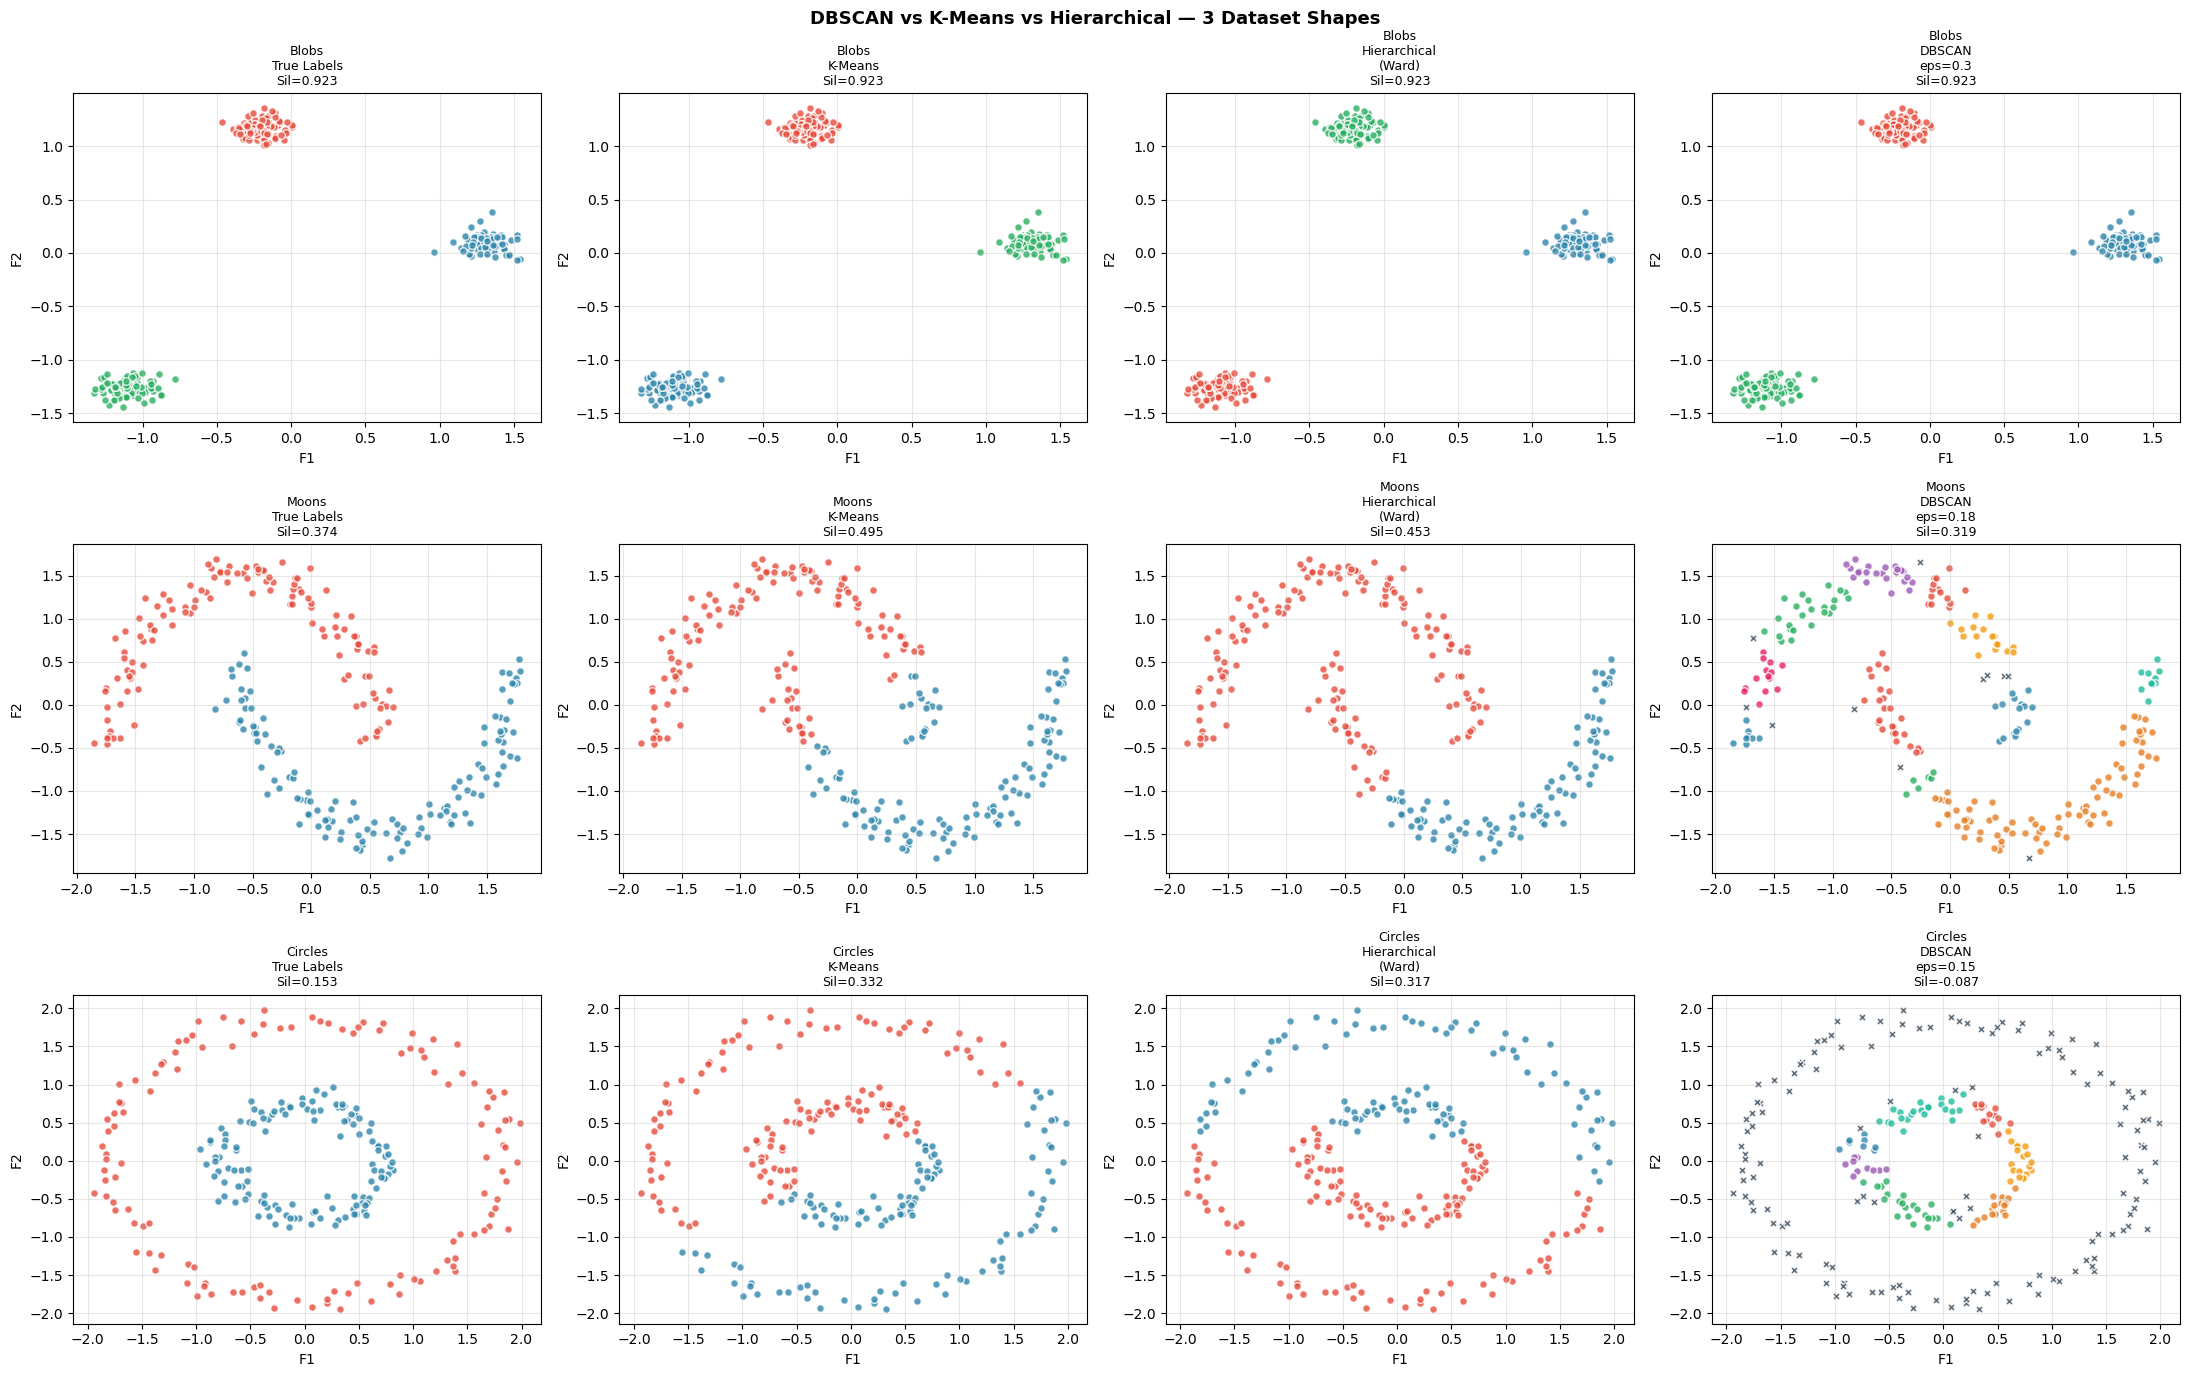

In [7]:
np.random.seed(42)
comp_datasets = {
    'Blobs':   make_blobs(n_samples=250, centers=3, cluster_std=0.5, random_state=42),
    'Moons':   make_moons(n_samples=250, noise=0.07, random_state=42),
    'Circles': make_circles(n_samples=250, noise=0.05, factor=0.4, random_state=42),
}
dbscan_params = {
    'Blobs':   (0.3, 5),
    'Moons':   (0.18, 5),
    'Circles': (0.15, 5),
}

fig, axes = plt.subplots(3, 4, figsize=(22, 14))

for row, (name, (X_c, y_c)) in enumerate(comp_datasets.items()):
    X_c_sc = StandardScaler().fit_transform(X_c)
    n_k    = len(np.unique(y_c))
    eps_c, ms_c = dbscan_params[name]

    models = {
        'True Labels':      y_c,
        'K-Means':          KMeans(n_clusters=n_k, init='k-means++', n_init=10, random_state=42).fit_predict(X_c_sc),
        'Hierarchical\n(Ward)': AgglomerativeClustering(n_clusters=n_k, linkage='ward').fit_predict(X_c_sc),
        f'DBSCAN\neps={eps_c}':   DBSCAN(eps=eps_c, min_samples=ms_c).fit_predict(X_c_sc),
    }

    for col, (mname, lbl) in enumerate(models.items()):
        ax = axes[row][col]
        for k in np.unique(lbl):
            mask   = lbl == k
            color  = COLORS['noise'] if k == -1 else CLUSTER_COLORS[int(k) % len(CLUSTER_COLORS)]
            marker = 'X' if k == -1 else 'o'
            ax.scatter(X_c_sc[mask, 0], X_c_sc[mask, 1],
                       color=color, s=30, marker=marker,
                       alpha=0.8, edgecolors='white')
        valid = np.unique(lbl[lbl >= 0])
        if len(valid) > 1 and len(valid) < len(lbl) - 1:
            sil = silhouette_score(X_c_sc, lbl)
            ax.set_title(f'{name}\n{mname}\nSil={sil:.3f}', fontsize=9)
        else:
            ax.set_title(f'{name}\n{mname}', fontsize=9)
        ax.set_xlabel('F1'); ax.set_ylabel('F2')

plt.suptitle('DBSCAN vs K-Means vs Hierarchical — 3 Dataset Shapes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Real-World Offline-Safe Dataset — Geospatial-Style Event Clustering

Total events : 265
True hotspots: 4
Noise events : 25


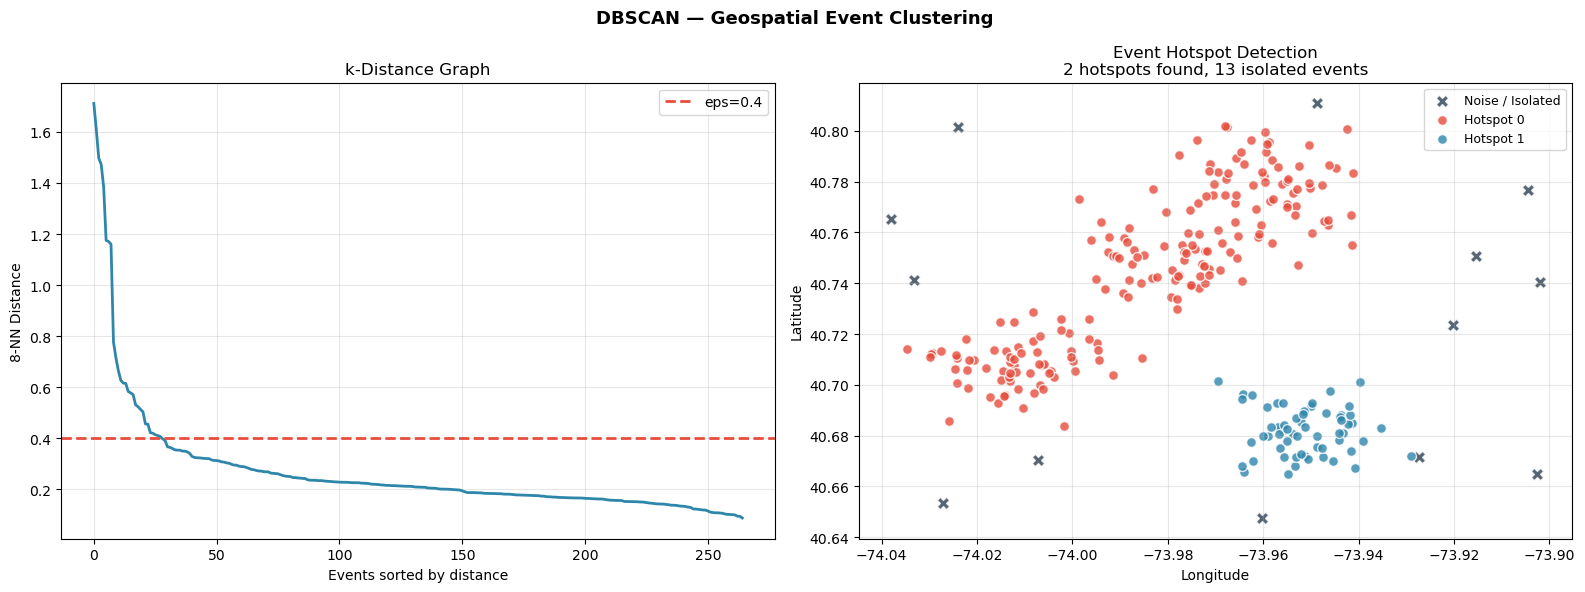

Hotspots detected : 2 (true: 4)
Isolated events   : 13 (true noise: 25)


In [8]:
np.random.seed(42)

# Simulate event locations across a city (lat/lon style)
# Dense hotspots + sparse noise events
hotspot_centers = [
    [40.71, -74.01],   # Downtown
    [40.75, -73.98],   # Midtown
    [40.68, -73.95],   # Brooklyn
    [40.78, -73.96],   # Upper West
]
n_per_hotspot = 60
n_noise_pts   = 25

event_coords = []
for center in hotspot_centers:
    pts = np.random.randn(n_per_hotspot, 2) * 0.01 + center
    event_coords.append(pts)

# Add random noise events scattered widely
noise_pts = np.column_stack([
    np.random.uniform(40.65, 40.82, n_noise_pts),
    np.random.uniform(-74.05, -73.90, n_noise_pts)
])
event_coords.append(noise_pts)
X_geo = np.vstack(event_coords)

feat_names_geo = ['Latitude', 'Longitude']
print(f'Total events : {len(X_geo)}')
print(f'True hotspots: {len(hotspot_centers)}')
print(f'Noise events : {n_noise_pts}')

# Scale
sc_geo   = StandardScaler()
X_geo_sc = sc_geo.fit_transform(X_geo)

# k-distance to find eps
min_s_geo = 8
nbrs_geo  = NearestNeighbors(n_neighbors=min_s_geo).fit(X_geo_sc)
dist_geo, _ = nbrs_geo.kneighbors(X_geo_sc)
kdist_geo   = np.sort(dist_geo[:, -1])[::-1]

# Apply DBSCAN
eps_geo  = 0.4
db_geo   = DBSCAN(eps=eps_geo, min_samples=min_s_geo)
lbl_geo  = db_geo.fit_predict(X_geo_sc)
n_clust_geo = len(np.unique(lbl_geo[lbl_geo >= 0]))
n_noise_geo = (lbl_geo == -1).sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# k-distance graph
axes[0].plot(kdist_geo, color=COLORS['primary'], linewidth=2)
axes[0].axhline(eps_geo, color=COLORS['danger'], linestyle='--',
                linewidth=2, label=f'eps={eps_geo}')
axes[0].set_xlabel('Events sorted by distance')
axes[0].set_ylabel(f'{min_s_geo}-NN Distance')
axes[0].set_title('k-Distance Graph')
axes[0].legend()

# Cluster map
for k in np.unique(lbl_geo):
    mask   = lbl_geo == k
    color  = COLORS['noise'] if k == -1 else CLUSTER_COLORS[k % len(CLUSTER_COLORS)]
    marker = 'X' if k == -1 else 'o'
    size   = 80 if k == -1 else 50
    lbl_str = 'Noise / Isolated' if k == -1 else f'Hotspot {k}'
    axes[1].scatter(X_geo[mask, 1], X_geo[mask, 0],
                    color=color, s=size, marker=marker,
                    alpha=0.8, edgecolors='white', label=lbl_str)
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')
axes[1].set_title(
    f'Event Hotspot Detection\n{n_clust_geo} hotspots found, {n_noise_geo} isolated events'
)
axes[1].legend(fontsize=9)

plt.suptitle('DBSCAN — Geospatial Event Clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Hotspots detected : {n_clust_geo} (true: {len(hotspot_centers)})')
print(f'Isolated events   : {n_noise_geo} (true noise: {n_noise_pts})')

## 9. Parameter Grid — eps × min_samples Heatmap

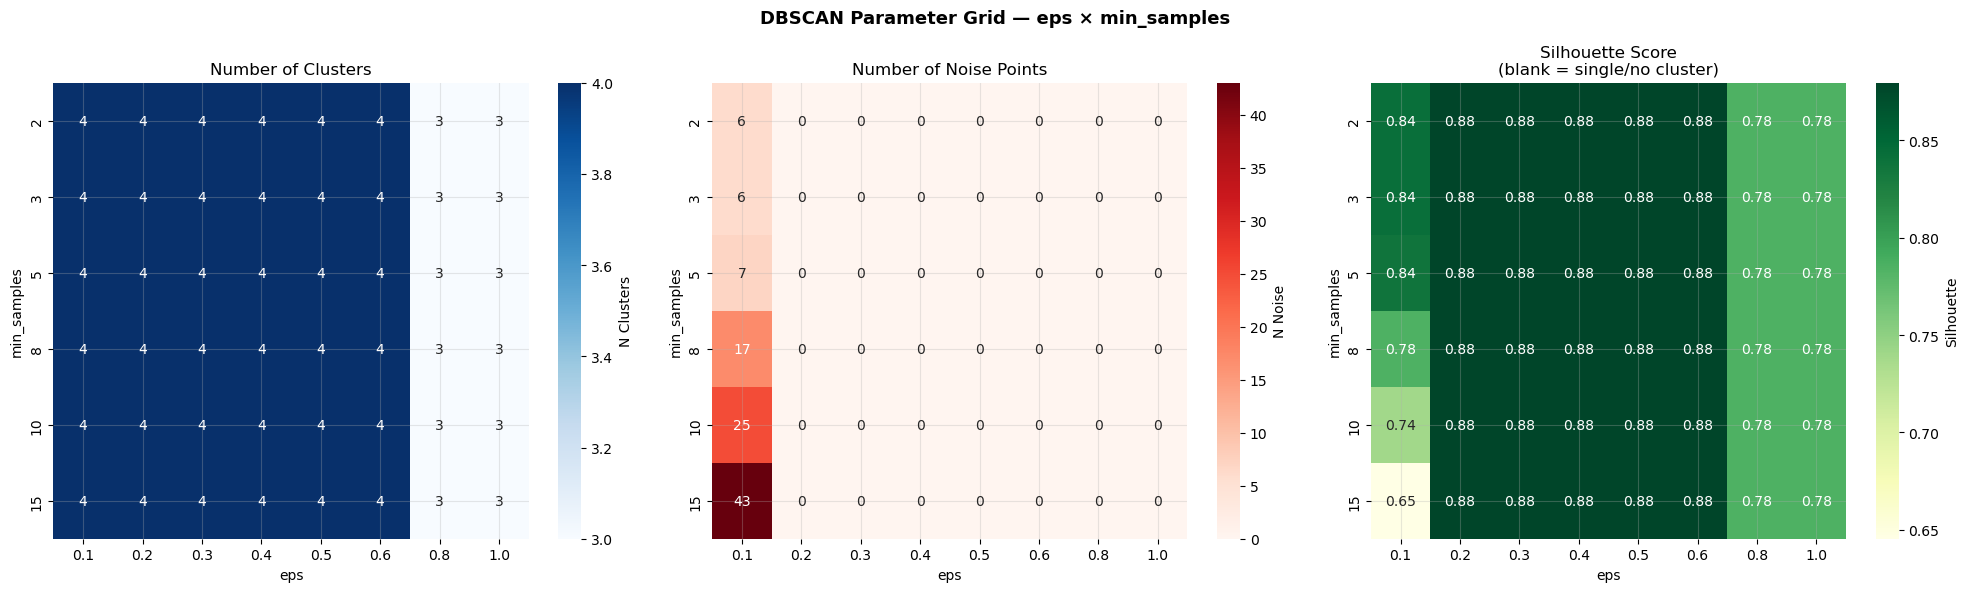

Best silhouette : 0.8796
  eps           : 0.2
  min_samples   : 2


In [9]:
np.random.seed(42)
X_grid, _ = make_blobs(n_samples=300, centers=4,
                        cluster_std=0.6, random_state=42)
X_grid_sc  = StandardScaler().fit_transform(X_grid)

eps_grid  = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0]
ms_grid   = [2, 3, 5, 8, 10, 15]

n_clusters_mat = np.zeros((len(ms_grid), len(eps_grid)))
n_noise_mat    = np.zeros((len(ms_grid), len(eps_grid)))
sil_mat        = np.full((len(ms_grid), len(eps_grid)), np.nan)

for i, ms in enumerate(ms_grid):
    for j, eps in enumerate(eps_grid):
        lbl = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_grid_sc)
        nc  = len(np.unique(lbl[lbl >= 0]))
        nn  = (lbl == -1).sum()
        n_clusters_mat[i, j] = nc
        n_noise_mat[i, j]    = nn
        if 1 < nc < len(lbl) - 1:
            sil_mat[i, j] = silhouette_score(X_grid_sc, lbl)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(n_clusters_mat, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=eps_grid, yticklabels=ms_grid, ax=axes[0],
            cbar_kws={'label': 'N Clusters'})
axes[0].set_xlabel('eps'); axes[0].set_ylabel('min_samples')
axes[0].set_title('Number of Clusters')

sns.heatmap(n_noise_mat, annot=True, fmt='.0f', cmap='Reds',
            xticklabels=eps_grid, yticklabels=ms_grid, ax=axes[1],
            cbar_kws={'label': 'N Noise'})
axes[1].set_xlabel('eps'); axes[1].set_ylabel('min_samples')
axes[1].set_title('Number of Noise Points')

sns.heatmap(sil_mat, annot=True, fmt='.2f', cmap='YlGn',
            xticklabels=eps_grid, yticklabels=ms_grid, ax=axes[2],
            cbar_kws={'label': 'Silhouette'}, mask=np.isnan(sil_mat))
axes[2].set_xlabel('eps'); axes[2].set_ylabel('min_samples')
axes[2].set_title('Silhouette Score\n(blank = single/no cluster)')

plt.suptitle('DBSCAN Parameter Grid — eps × min_samples',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_idx = np.unravel_index(np.nanargmax(sil_mat), sil_mat.shape)
print(f'Best silhouette : {sil_mat[best_idx]:.4f}')
print(f'  eps           : {eps_grid[best_idx[1]]}')
print(f'  min_samples   : {ms_grid[best_idx[0]]}')

## 10. DBSCAN Limitations & When to Use What

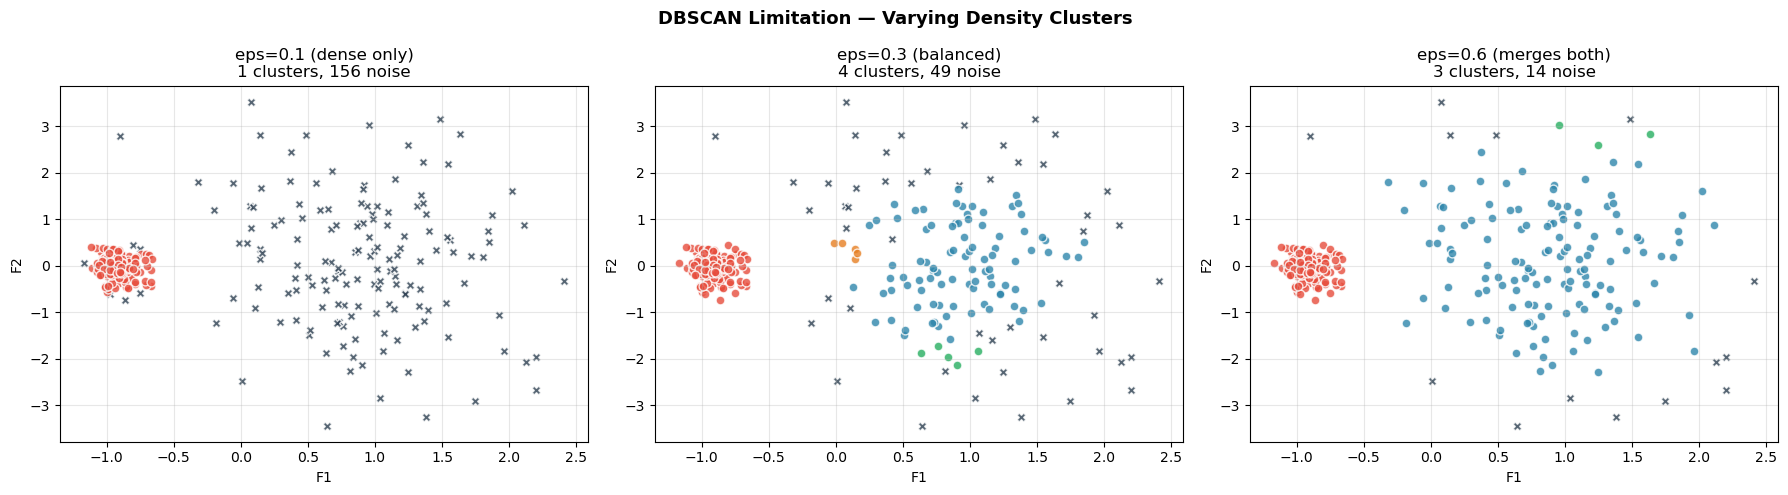

DBSCAN uses a single global eps -> struggles with clusters of different densities.
Solution -> HDBSCAN (Hierarchical DBSCAN) handles varying densities automatically.

Algorithm Selection Guide:
  K-Means      : Large data, spherical clusters, K known
  Hierarchical : Small data, K unknown, need dendrogram
  DBSCAN       : Arbitrary shapes, outlier detection, K unknown
  HDBSCAN      : Varying density clusters, robust noise detection


In [10]:
# Varying density — DBSCAN's main weakness
np.random.seed(42)
X_dense, _ = make_blobs(n_samples=150, centers=1,
                         cluster_std=0.2, random_state=0)
X_sparse, _ = make_blobs(n_samples=150, centers=1,
                          cluster_std=1.2, random_state=1)
X_sparse[:, 0] += 6
X_vary = np.vstack([X_dense, X_sparse])
X_vary_sc = StandardScaler().fit_transform(X_vary)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, eps_v, title in zip(
    axes,
    [0.1, 0.3, 0.6],
    ['eps=0.1 (dense only)','eps=0.3 (balanced)','eps=0.6 (merges both)']
):
    lbl = DBSCAN(eps=eps_v, min_samples=5).fit_predict(X_vary_sc)
    nc  = len(np.unique(lbl[lbl >= 0]))
    nn  = (lbl == -1).sum()
    for k in np.unique(lbl):
        mask   = lbl == k
        color  = COLORS['noise'] if k == -1 else CLUSTER_COLORS[k % len(CLUSTER_COLORS)]
        marker = 'X' if k == -1 else 'o'
        ax.scatter(X_vary_sc[mask, 0], X_vary_sc[mask, 1],
                   color=color, s=40, marker=marker, alpha=0.8, edgecolors='white')
    ax.set_title(f'{title}\n{nc} clusters, {nn} noise')
    ax.set_xlabel('F1'); ax.set_ylabel('F2')

plt.suptitle('DBSCAN Limitation — Varying Density Clusters',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('DBSCAN uses a single global eps -> struggles with clusters of different densities.')
print('Solution -> HDBSCAN (Hierarchical DBSCAN) handles varying densities automatically.')
print()
print('Algorithm Selection Guide:')
print('  K-Means      : Large data, spherical clusters, K known')
print('  Hierarchical : Small data, K unknown, need dendrogram')
print('  DBSCAN       : Arbitrary shapes, outlier detection, K unknown')
print('  HDBSCAN      : Varying density clusters, robust noise detection')

## 11. Final Summary & Key Takeaways

In [11]:
print('=' * 68)
print('              DBSCAN - KEY TAKEAWAYS')
print('=' * 68)

takeaways = [
    ('Core idea',        'Cluster = dense region; noise = isolated low-density point'),
    ('No K needed',      'Number of clusters determined automatically by density'),
    ('Noise detection',  'Points labeled -1 are outliers/anomalies — built-in'),
    ('Arbitrary shapes', 'Finds moons, circles, elongated clusters K-Means cannot'),
    ('eps',              'Neighborhood radius; too small = fragmented, too large = merged'),
    ('min_samples',      'Min points for core; higher = stricter, more noise labeled'),
    ('k-distance graph', 'Elbow in k-NN distances suggests good eps value'),
    ('Scaling',          'ALWAYS scale — DBSCAN is distance-based'),
    ('Deterministic',    'No random init — same result every run'),
    ('Silhouette',       'Excludes noise points (-1) from score calculation'),
    ('Complexity',       'O(n log n) with KD-tree; O(n^2) without spatial index'),
    ('Limitation',       'Single global eps fails on varying-density clusters'),
    ('Remedy',           'HDBSCAN handles varying density clusters robustly'),
    ('Use cases',        'Geospatial hotspots, fraud detection, anomaly detection'),
]

for topic, detail in takeaways:
    print(f'  OK  {topic:<20}  ->  {detail}')

print('=' * 68)

              DBSCAN - KEY TAKEAWAYS
  OK  Core idea             ->  Cluster = dense region; noise = isolated low-density point
  OK  No K needed           ->  Number of clusters determined automatically by density
  OK  Noise detection       ->  Points labeled -1 are outliers/anomalies — built-in
  OK  Arbitrary shapes      ->  Finds moons, circles, elongated clusters K-Means cannot
  OK  eps                   ->  Neighborhood radius; too small = fragmented, too large = merged
  OK  min_samples           ->  Min points for core; higher = stricter, more noise labeled
  OK  k-distance graph      ->  Elbow in k-NN distances suggests good eps value
  OK  Scaling               ->  ALWAYS scale — DBSCAN is distance-based
  OK  Deterministic         ->  No random init — same result every run
  OK  Silhouette            ->  Excludes noise points (-1) from score calculation
  OK  Complexity            ->  O(n log n) with KD-tree; O(n^2) without spatial index
  OK  Limitation            ->  Sin

---
## Practice Exercises

1. **Sweep eps from 0.05 to 1.0** on the moons dataset and plot n_clusters and n_noise vs eps.
2. **Compare k-distance elbows** for k=3, 5, 10 — does the suggested eps differ significantly?
3. **Apply DBSCAN to the customer segmentation dataset** from the K-Means notebook — which algorithm finds more meaningful groups?
4. **Build an anomaly detection pipeline** — fit DBSCAN, extract noise points, and profile them.
5. **Try HDBSCAN** — `pip install hdbscan` and compare on the varying-density dataset from Section 10.
6. **Implement DBSCAN from scratch** using only NumPy and a distance matrix — verify it matches sklearn.

---
*Notebook created for the ML Repository — DBSCAN module.*